In [15]:
import os

# Eski veritabanı dosyasını sil
if os.path.exists("butce.db"):
    os.remove("butce.db")
    print("🧹 Eski veritabanı silindi, yeni tablo yapısına hazır!")

🧹 Eski veritabanı silindi, yeni tablo yapısına hazır!



💬 DOĞAL DİL İLE KİŞİSEL HARCAMA TAKİPÇİSİ
Harcamanızı günlük dille yazın (Örn: 'kahve içtim 200')
Komutlar: 'liste' (Tüm harcamalar), 'ozet' (Rapor), 'grafik', 'cikis'

👉 Harcama veya Komut Girin: sinema 200 tl

✨ Anlaşıldı ve Kaydedildi!
📌 Harcama Yeri / Kategori : Sinema
💵 Tutar                   : 200.0 TL

💬 DOĞAL DİL İLE KİŞİSEL HARCAMA TAKİPÇİSİ
Harcamanızı günlük dille yazın (Örn: 'kahve içtim 200')
Komutlar: 'liste' (Tüm harcamalar), 'ozet' (Rapor), 'grafik', 'cikis'

👉 Harcama veya Komut Girin: yemek yedim 500

✨ Anlaşıldı ve Kaydedildi!
📌 Harcama Yeri / Kategori : Yemek
💵 Tutar                   : 500.0 TL

💬 DOĞAL DİL İLE KİŞİSEL HARCAMA TAKİPÇİSİ
Harcamanızı günlük dille yazın (Örn: 'kahve içtim 200')
Komutlar: 'liste' (Tüm harcamalar), 'ozet' (Rapor), 'grafik', 'cikis'

👉 Harcama veya Komut Girin: grafik


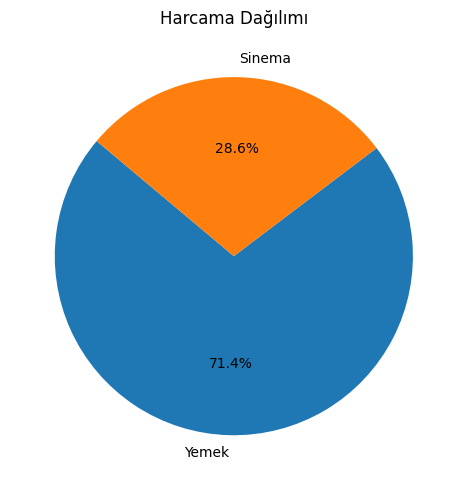


💬 DOĞAL DİL İLE KİŞİSEL HARCAMA TAKİPÇİSİ
Harcamanızı günlük dille yazın (Örn: 'kahve içtim 200')
Komutlar: 'liste' (Tüm harcamalar), 'ozet' (Rapor), 'grafik', 'cikis'

👉 Harcama veya Komut Girin: çıkış
❌ Cümle içinde herhangi bir harcama tutarı (sayı) bulunamadı!

💬 DOĞAL DİL İLE KİŞİSEL HARCAMA TAKİPÇİSİ
Harcamanızı günlük dille yazın (Örn: 'kahve içtim 200')
Komutlar: 'liste' (Tüm harcamalar), 'ozet' (Rapor), 'grafik', 'cikis'

👉 Harcama veya Komut Girin: cikis
Uygulama kapatıldı.


In [16]:
import sqlite3
import re
import os
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

class NaturalLanguageBudgetTracker:
    def __init__(self, db_name="butce.db"):
        self.conn = sqlite3.connect(db_name)
        self.cursor = self.conn.cursor()
        self.setup_database()

    def setup_database(self):
        """Yeni tablo yapısını oluşturur."""
        self.cursor.execute('''
            CREATE TABLE IF NOT EXISTS harcamalar (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                miktar REAL NOT NULL,
                kategori TEXT NOT NULL,
                ham_cumle TEXT,
                tarih DATE NOT NULL
            )
        ''')
        self.conn.commit()

    def cumleyi_cozumle_ve_ekle(self, cumle):
        """Yazılan metinden tutarı ve harcama yerini ayıklar."""
        sayilar = re.findall(r'\d+(?:\.\d+)?', cumle)

        if not sayilar:
            print("❌ Cümle içinde herhangi bir harcama tutarı (sayı) bulunamadı!")
            return

        miktar = float(sayilar[0])

        temiz_cumle = cumle.lower()
        dolgu_kelimeleri = [
            'tl', 'lira', 'para', 'verdim', 'harcadım', 'aldım', 'ödedim',
            'içtim', 'yedim', 'bugün', 'dün', 'için', 'tane', 'satın'
        ]

        temiz_cumle = re.sub(r'\d+(?:\.\d+)?', '', temiz_cumle)

        for kelime in dolgu_kelimeleri:
            temiz_cumle = temiz_cumle.replace(kelime, '')

        kategori = temiz_cumle.strip().capitalize()
        if not kategori:
            kategori = "Genel Harcama"

        tarih = datetime.now().strftime("%Y-%m-%d %H:%M")

        self.cursor.execute('''
            INSERT INTO harcamalar (miktar, kategori, ham_cumle, tarih)
            VALUES (?, ?, ?, ?)
        ''', (miktar, kategori, cumle, tarih))
        self.conn.commit()

        print(f"\n✨ Anlaşıldı ve Kaydedildi!")
        print(f"📌 Harcama Yeri / Kategori : {kategori}")
        print(f"💵 Tutar                   : {miktar} TL")

    def harcamalari_listele(self):
        query = 'SELECT id AS ID, tarih AS Tarih, kategori AS Harcama, miktar AS Tutar_TL, ham_cumle AS Girilen_Metin FROM harcamalar ORDER BY id DESC'
        return pd.read_sql_query(query, self.conn)

    def kategori_ozeti(self):
        query = 'SELECT kategori AS Harcama_Yeri, SUM(miktar) AS Toplam_TL, COUNT(id) AS Islem_Sayisi FROM harcamalar GROUP BY kategori ORDER BY Toplam_TL DESC'
        return pd.read_sql_query(query, self.conn)

    def grafik_ciz(self):
        df = self.kategori_ozeti()
        if df.empty:
            print("⚠️ Henüz kayıtlı harcama yok.")
            return
        plt.figure(figsize=(7, 5))
        plt.pie(df['Toplam_TL'], labels=df['Harcama_Yeri'], autopct='%1.1f%%', startangle=140)
        plt.title('Harcama Dağılımı')
        plt.tight_layout()
        plt.show()

# Eski uyumsuz veritabanı dosyasını sıfırla
if os.path.exists("butce.db"):
    try:
        os.remove("butce.db")
    except:
        pass

def main():
    tracker = NaturalLanguageBudgetTracker()

    while True:
        print("\n" + "="*50)
        print("💬 DOĞAL DİL İLE KİŞİSEL HARCAMA TAKİPÇİSİ")
        print("="*50)
        print("Harcamanızı günlük dille yazın (Örn: 'kahve içtim 200')")
        print("Komutlar: 'liste' (Tüm harcamalar), 'ozet' (Rapor), 'grafik', 'cikis'")

        girdi = input("\n👉 Harcama veya Komut Girin: ").strip()

        if not girdi:
            continue

        if girdi.lower() == 'cikis':
            print("Uygulama kapatıldı.")
            break
        elif girdi.lower() == 'liste':
            df = tracker.harcamalari_listele()
            print("\n📋 TÜM HARCAMALAR:")
            print(df.to_string(index=False) if not df.empty else "Henüz harcama yok.")
        elif girdi.lower() == 'ozet':
            df_ozet = tracker.kategori_ozeti()
            print("\n📊 HARCAMA ÖZETİ:")
            print(df_ozet.to_string(index=False) if not df_ozet.empty else "Henüz harcama yok.")
        elif girdi.lower() == 'grafik':
            tracker.grafik_ciz()
        else:
            tracker.cumleyi_cozumle_ve_ekle(girdi)

if __name__ == "__main__":
    main()